---
title: Three fields — a fully non-stationary GEV
subtitle: Giving the shape ξ(s) its own Gaussian process too, and asking whether it helps
short_title: Spatial μ, σ and ξ
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - non-stationary extremes
  - Gaussian process
  - spatial shape parameter
  - identifiability
  - variational inference
abstract: |
  The last step of the spatial build-up: every GEV parameter becomes its own
  Gaussian-process field. On top of the location μ(s) and scale σ(s) of notebook
  08, the **shape** ξ(s) — the tail exponent — gets a third GP. The model is
  fully non-stationary, and fits with the same mean-field variational
  approximation as notebook 08. The point
  is as much diagnostic as predictive: ξ is barely identifiable even pooled
  globally (notebook 04), so we ask honestly whether a spatial prior can recover
  any tail geography, or whether the ξ(s) field just reproduces per-station
  noise. The answer shapes how far non-stationarity is worth pushing.
---

# Three fields: a fully non-stationary spatial GEV

Notebook 07 made the **location** spatial; notebook 08 added a spatial **scale**.
The only parameter still forced to a single global value is the **shape** $\xi$ —
the tail exponent that decides whether extremes are bounded ($\xi<0$), light
($\xi=0$) or heavy ($\xi>0$). This notebook frees it too, giving the GEV a third
Gaussian-process field and making it **fully non-stationary**:

$$
y_{s,t} \sim \mathrm{GEV}\big(\mu(s),\ \sigma(s),\ \xi(s)\big),
$$

$$
\begin{aligned}
\mu(s) &= \mu_0 + f_\mu(s) + \varepsilon^\mu_s, \\
\log\sigma(s) &= \lambda_0 + f_\sigma(s) + \varepsilon^\sigma_s, \\
\tilde\xi(s) &= \xi_0 + f_\xi(s) + \varepsilon^\xi_s, \qquad
\xi(s) = \tfrac12\tanh\tilde\xi(s),
\end{aligned}
$$

with **three independent** Matérn-3/2 GP fields, each with a fixed regional
lengthscale and a fixed amplitude, plus per-station nuggets. The $\tfrac12\tanh$
keeps $\xi(s)$ in the stable, finite-mean band $(-\tfrac12, \tfrac12)$ from
notebook 04.

This is the natural end of the build-up — but more parameters is not the same as
more *knowledge*. Notebook 04 showed $\xi$ is dominated by sampling noise even
when estimated per station, and notebook 05 showed a hierarchy pools it almost to
a constant. So the real question here is **diagnostic**: given a free spatial
field, does $\xi(s)$ discover any tail geography, or does it just paint the old
per-station noise onto a map? We give $f_\xi$ a deliberately small prior amplitude
— the honest prior is that the tail barely varies — and look.

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoLaplaceApproximation, AutoNormal
from numpyro.infer.initialization import init_to_median, init_to_value

from pyrox_gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data, results
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)                       # (S, T) — NaN where a year is missing
mask = ~jnp.isnan(Y)
S, T = Y.shape
lon, lat = stations[:, 0], stations[:, 1]
Xs = jnp.asarray(stations)
Xm, Xsd = Xs.mean(0), Xs.std(0)
Xn = (Xs - Xm) / Xsd                          # standardised coords for the kernel
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
# Regional lengthscale, in standardised (lon, lat) units. Notebook 06 fitted
# this on the same inputs; use its value when cached, else the original literal.
_gp_hyp = results.load_fit("gp_primer_hypers", expect_real=is_real)
LENGTHSCALE = float(_gp_hyp["lengthscale"]) if _gp_hyp is not None else 0.8
print("lengthscale:", f"{LENGTHSCALE:.2f}",
      "(from notebook 06)" if _gp_hyp is not None else "(default - run nb 06 to fit it)")
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")

# physical covariates for the scale field (derived in notebook 06),
# standardised so each coefficient is the log-σ change per 1 SD of the feature
from spatial_extremes.features import load_station_features

_feat = load_station_features(stations)
COV_COLS = ["elevation", "dist_coast_km"]
COV_LABELS = ["elevation", "dist-to-coast"]
_C = _feat[COV_COLS].to_numpy()
C = jnp.asarray((_C - _C.mean(0)) / _C.std(0))   # (S, n_cov)

/home/azureuser/localfiles/research/research_notebook/.claude/worktrees/spatial-extremes-refresh/projects/spatial_extremes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


lengthscale: 0.91 (from notebook 06)
source: REAL | stations 107 | years 1897-2025 (125)


## The three-field model

The same `gp_field` helper as notebook 08, now called three times — each GP again
uses a **fixed** lengthscale *and* amplitude (notebook 08 explains why a free
amplitude is only weakly identified and destabilises the fit). The fixed
amplitudes say how far we let each parameter roam: a few °C for the location,
~20% (in log units) for the scale, and a **deliberately tight** band for the
shape — its honest setting is "nearly constant", so the data must work hard to
move it.

As in notebook 08, the **scale** also carries a linear covariate trend in
elevation and distance-to-coast,
$\log\sigma(s) = \lambda_0 + \beta^\top c(s) + f_\sigma(s) + \varepsilon^\sigma_s$ —
08 showed elevation (not raw coordinates) is what the regional scale structure
was really tracking, so we keep it here too.

In [4]:
def gp_field(name, var, Xn):
    """A centred, whitened Matérn-3/2 GP with fixed lengthscale and amplitude."""
    k = Matern(pyrox_name="k_" + name, nu=1.5,
               init_lengthscale=LENGTHSCALE, init_variance=var)
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)

def model(Xn, Y=None):
    f_mu = gp_field("mu", 4.0, Xn)            # location field (°C)
    f_ls = gp_field("ls", 0.1, Xn)            # log-scale field (log units)
    f_xi = gp_field("xi", 0.05, Xn)           # shape field (tanh pre-image)

    mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
    lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
    beta_ls = numpyro.sample(
        "beta_ls", ndist.Normal(0.0, 0.5).expand([C.shape[1]]).to_event(1))
    xi0 = numpyro.sample("xi0", ndist.Normal(0.0, 0.3))
    tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))
    tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(0.3))
    tau_xi = numpyro.sample("tau_xi", ndist.HalfNormal(0.15))
    with numpyro.plate("stations", S):
        z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
        z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))
        z_xi = numpyro.sample("z_xi", ndist.Normal(0.0, 1.0))

    cov_ls = numpyro.deterministic("cov_ls", C @ beta_ls)   # covariate trend on log-σ
    mu_field = numpyro.deterministic("mu_field", mu0 + f_mu + tau_mu * z_mu)
    sigma_field = numpyro.deterministic(
        "sigma_field", jnp.exp(lam0 + cov_ls + f_ls + tau_ls * z_ls))
    xi_field = numpyro.deterministic(
        "xi_field", 0.5 * jnp.tanh(xi0 + f_xi + tau_xi * z_xi))
    numpyro.deterministic("f_xi_s", f_xi)

    if Y is not None:
        yf = jnp.where(mask, Y, ybar[:, None])
        lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                 concentration=xi_field[:, None]).log_prob(yf)
        numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

## Fit with mean-field VI

warm start <- notebooks/03_spatial_gev/07_spatial_gp_mu.ipynb @ 28243b1 (2026-08-21T17:37:52+00:00)


Mean-field VI fit in 351.6s · final ELBO loss 13989.7


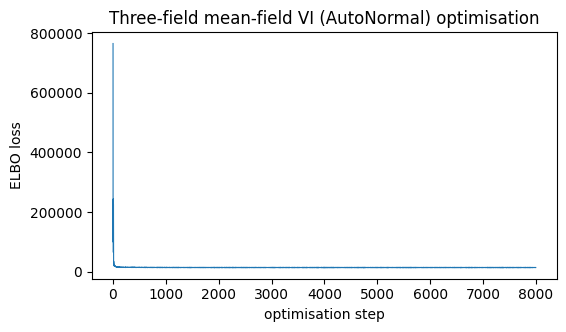

In [5]:
# Warm start from notebook 07. The whitened field u transfers directly between
# the two models - both put a Matern-3/2 over the same standardised coordinates
# with the same lengthscale, so u lives in the same N(0, I) space and needs no
# un-whitening.
#
# We transfer the *location* only. Seeding the shape at notebook 07's fitted
# xi = -0.21 would pin a hard GEV upper bound mu + sigma/|xi|, and two of these
# 107 stations have recorded a maximum above their own bound - an initial
# log-density of -inf, and the optimiser cannot start. Left at its prior median
# the shape begins at xi = 0 (Gumbel, unbounded), which is always safe. The
# geography is what notebook 07 actually learned; each model can find its own
# tail.
_sp = results.load_fit("spatial_gp_mu", expect_real=is_real)
if _sp is not None and _sp["f_u_med"].shape == (S,):
    _seed = {"f_mu_u": jnp.asarray(_sp["f_u_med"]),
             "mu0": float(np.median(_sp["mu_field_med"]))}

    def init_fn(site=None, **kwargs):
        """Seeded where we have a value, prior median everywhere else.

        `init_to_value` falls back to a *uniform* draw for sites it is not
        given, which here can start the shape field far from zero and back us
        into the support problem above. Falling back to the median keeps every
        unseeded site exactly where the cold run would have put it.
        """
        if site is not None and site["name"] in _seed:
            return init_to_value(site, values=_seed)
        return init_to_median(site, **kwargs)

    print(results.describe_fit(_sp))
else:
    init_fn = init_to_median
    print("no cached notebook-07 fit - cold start (init_to_median)")

guide = AutoNormal(model, init_loc_fn=init_fn)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(1e-2))
)
svi = SVI(model, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 8000, Xn, Y, progress_bar=False)
losses = np.asarray(res.losses)
finite = losses[np.isfinite(losses)]
print(f"Mean-field VI fit in {time.time() - t0:.1f}s · final ELBO loss "
      f"{float(finite[-1]):.1f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.where(np.isfinite(losses), losses, np.nan), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Three-field mean-field VI (AutoNormal) optimisation")
plt.show()

## Read off the three fields

In [6]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(600,))
pred = Predictive(model, posterior_samples=lap,
                  return_sites=["mu_field", "sigma_field", "xi_field", "f_xi_s",
                                "beta_ls", "cov_ls"])
draws = pred(jr.PRNGKey(2), Xn)

mu_field = np.asarray(draws["mu_field"])
sigma_field = np.asarray(draws["sigma_field"])
xi_field = np.asarray(draws["xi_field"])
f_xi = np.asarray(draws["f_xi_s"])
mu_med = mu_field.mean(0)
sig_med = sigma_field.mean(0)
xi_med = xi_field.mean(0)

print(f"μ(s) range : {mu_med.min():.1f} -> {mu_med.max():.1f} °C")
print(f"σ(s) range : {sig_med.min():.2f} -> {sig_med.max():.2f} °C")
print(f"ξ(s) range : {xi_med.min():+.3f} -> {xi_med.max():+.3f} "
      f"(global ξ in nb 07/08 was ≈ -0.19)")

beta = np.asarray(draws["beta_ls"])              # (n, n_cov)
print("log-σ covariate effects (per 1 SD, 95% CI):")
for j, labj in enumerate(COV_LABELS):
    lo, hi = np.quantile(beta[:, j], [0.025, 0.975])
    flag = "← excludes 0" if (lo > 0 or hi < 0) else ""
    print(f"  β[{labj:13s}] = {beta[:, j].mean():+.3f}  ({lo:+.2f}, {hi:+.2f})  {flag}")

μ(s) range : 21.0 -> 43.3 °C
σ(s) range : 1.44 -> 4.04 °C
ξ(s) range : -0.331 -> +0.018 (global ξ in nb 07/08 was ≈ -0.19)
log-σ covariate effects (per 1 SD, 95% CI):
  β[elevation    ] = -0.088  (-0.10, -0.07)  ← excludes 0
  β[dist-to-coast] = -0.036  (-0.05, -0.02)  ← excludes 0


## All three surfaces

Location, scale, and the newly-freed **shape**. Read the $\xi(s)$ panel
sceptically — and against the per-station $\xi$ scatter of notebook 04.

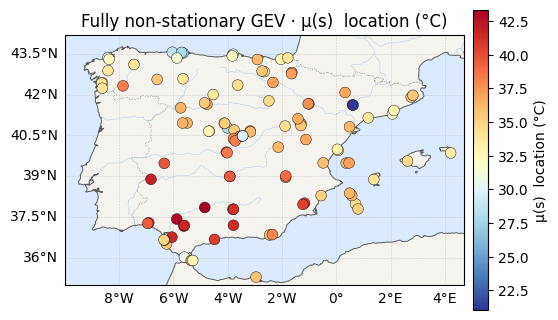

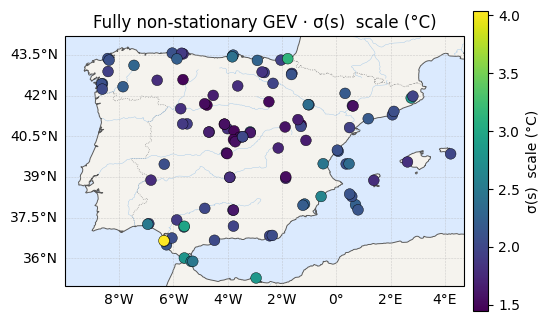

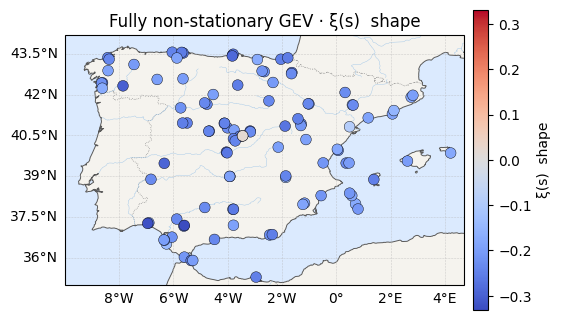

In [7]:
xa = np.abs(xi_med).max()
for vals, label, cmap, clim in [
    (mu_med, "μ(s)  location (°C)", "RdYlBu_r", None),
    (sig_med, "σ(s)  scale (°C)", "viridis", None),
    (xi_med, "ξ(s)  shape", "coolwarm", (-xa, xa)),
]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    sc = scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    if clim is not None:
        sc.set_clim(*clim)
    ax.set_title(f"Fully non-stationary GEV · {label}")
    plt.show()

## Did freeing ξ buy anything?

The decisive check is **signal vs noise** for the shape field, the same ratio as
notebook 04: the spread of $\xi(s)$ across stations over the typical per-station
95% interval width. A value well below 1 means the across-station differences are
small next to the uncertainty on each one — the map is mostly noise. (As in
notebook 08 we *fix* the $f_\xi$ amplitude rather than learn it, so it is this
ratio — not an imposed field amplitude — that carries the verdict.)

ξ(s) signal/noise = SD(median) / mean CI width = 0.044 / 0.321 = 0.14
=> signal/noise 0.14 << 1: the across-station spread of ξ(s) is small next to
   the per-station uncertainty — little or no recoverable tail geography.


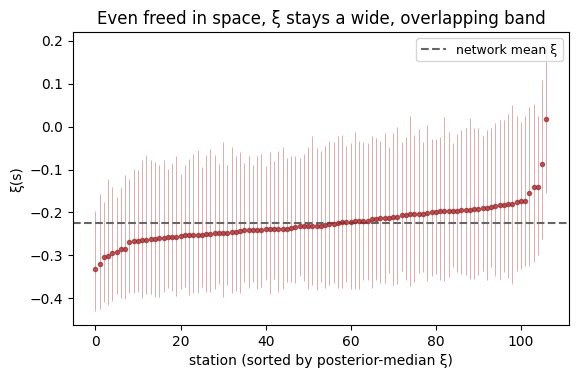

In [8]:
xi_lo = np.quantile(xi_field, 0.025, 0)
xi_hi = np.quantile(xi_field, 0.975, 0)
snr = xi_med.std() / (xi_hi - xi_lo).mean()
print(f"ξ(s) signal/noise = SD(median) / mean CI width = "
      f"{xi_med.std():.3f} / {(xi_hi - xi_lo).mean():.3f} = {snr:.2f}")
print(f"=> signal/noise {snr:.2f} << 1: the across-station spread of ξ(s) is small "
      "next to\n   the per-station uncertainty — little or no recoverable tail "
      "geography.")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
order = np.argsort(xi_med)
x = np.arange(xi_med.size)
ax.errorbar(x, xi_med[order],
            yerr=[xi_med[order] - xi_lo[order], xi_hi[order] - xi_med[order]],
            fmt="o", ms=3, lw=0.5, color="#9b2226", ecolor="#bb5a5a", alpha=0.7)
ax.axhline(xi_med.mean(), ls="--", color="0.4", label="network mean ξ")
ax.set_xlabel("station (sorted by posterior-median ξ)")
ax.set_ylabel("ξ(s)")
ax.set_title("Even freed in space, ξ stays a wide, overlapping band")
ax.legend(fontsize=9)
plt.show()

## Return levels — does the map move?

If the tail field is mostly noise, the $z_{100}$ map should look much like the
two-field model's, but with **wider** intervals — the extra freedom in $\xi$ adds
variance without adding signal. That trade-off is the whole lesson.

z100 median range : 25.3 -> 48.8 °C
z100 95% CI width : 10.3 °C avg (max 20.0) [nb 07 ≈ 2.7, nb 08 two-field for comparison]


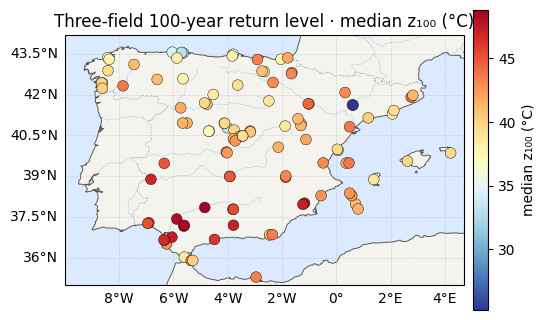

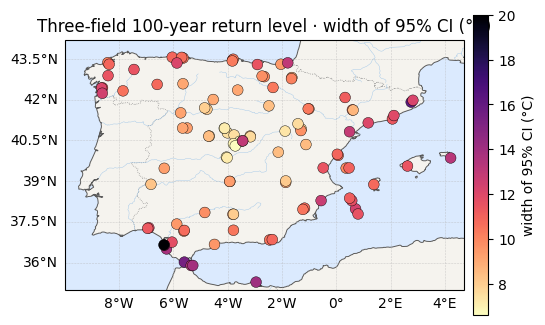

In [9]:
RL = np.asarray(gev_return_level(
    100.0, jnp.asarray(mu_field), jnp.asarray(sigma_field),
    jnp.asarray(xi_field)))                    # (n, S)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range : {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width : {rl_ciw.mean():.1f} °C avg (max {rl_ciw.max():.1f}) "
      f"[nb 07 ≈ 2.7, nb 08 two-field for comparison]")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Three-field 100-year return level · {label}")
    plt.show()

## Hand-off: cache the three fields

Cache μ(s), σ(s) and ξ(s) so the non-stationary notebooks can quote what the
*fully* spatial model thinks of a single station. Notebook 12 warm-starts from
notebook 07's fit rather than this one — 07's Laplace posterior is the better
anchor (compare the return-level intervals here with 07's) — and that choice is
itself the lesson: **warm-start from the fit you trust**.


In [10]:
from spatial_extremes import results

path = results.save_fit(
    "spatial_gp_fields",
    source="notebooks/03_spatial_gev/09_spatial_gp_mu_sigma_xi.ipynb",
    is_real=is_real,
    stations=np.asarray(stations),
    mu_med=np.median(np.asarray(draws["mu_field"]), axis=0),
    sigma_med=np.median(np.asarray(draws["sigma_field"]), axis=0),
    xi_med=np.median(np.asarray(draws["xi_field"]), axis=0),
)
print("cached ->", path)

cached -> /home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/cds_insitu/spatial_extremes/results/spatial_gp_fields.npz


## Takeaway — where non-stationarity stops paying

The machinery scales effortlessly: three independent GP fields fit in the same
few seconds, and the location and scale surfaces match notebooks 07–08. But the
**shape** tells the cautionary half of the story. Freed in space, $\xi(s)$ does
not resolve into geography — its signal-to-noise stays well below one and its
forest plot is the same wide, overlapping band we met at the very start in
notebook 04. The data simply do not
contain a recoverable map of the tail exponent; a spatial prior cannot conjure
one, and paying for it in extra parameters only widens the return-level
intervals.

That is the right note to end the build-up on. Spatial pooling is powerful
exactly where there is structure to borrow — the location, and the scale (which,
as the $\beta$ estimates above confirm, an **elevation covariate** carries better
than a free GP) — and honest about where there is not. The useful working model
for this dataset is notebook 08's: a spatial location, an **elevation-driven
scale**, and a **global** tail held in place by every station at once.